# 👩‍💻 Build and Visualize a Perceptron from Scratch

## 📋 Overview
In this lab, you will implement a perceptron from scratch using PyTorch tensors. You'll visualize the training process to understand how neural networks learn, including weight updates and decision boundary evolution. This hands-on experience provides fundamental insight into how neural networks operate before diving into more complex architectures.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:
- Implement a perceptron from scratch using PyTorch tensors
- Perform forward and backward passes manually with custom activation functions
- Visualize and interpret decision boundary evolution during training
- Experiment with learning rates and initial weights to understand their impact

## 🚀 Starting Point
Access the starter code below.

Required tools/setup:
- Python 3.x
- PyTorch
- NumPy
- Matplotlib
- scikit-learn

In [1]:
# Starter code
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

## Task 1: Create and Visualize a Synthetic Dataset
**Context:** As a machine learning engineer, you need a clear, linearly separable dataset to demonstrate how perceptrons learn. This synthetic data will help your team understand classification boundaries.

**Steps:**

1. Use scikit-learn's `make_classification` to generate a binary classification dataset with 2 features
2. Convert the data to NumPy arrays for visualization
3. Create a scatter plot colored by class to visualize the data distribution
4. Label axes appropriately and add a title


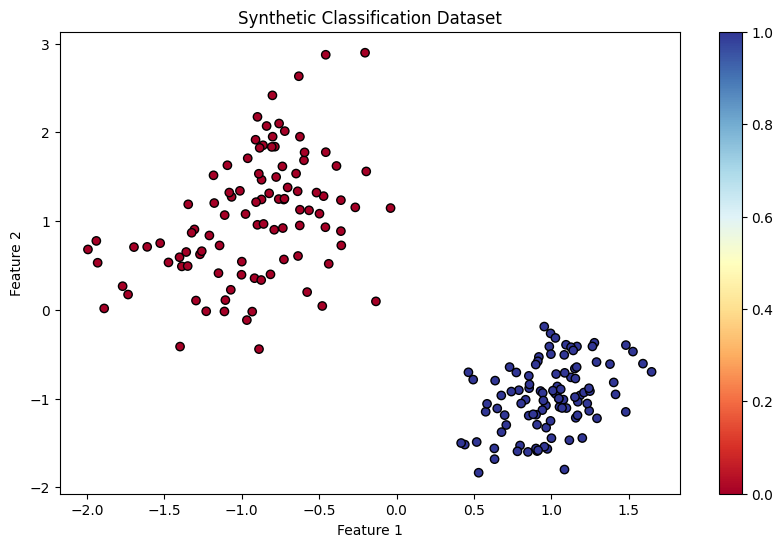

In [2]:
# Task 1: Generate and visualize the dataset
# Use make_classification with n_samples=200, n_features=2, n_redundant=0, 
# n_informative=2, n_clusters_per_class=1, class_sep=1.0
# Set class_sep parameter high enough to ensure linear separability

# You'll be generating data and building your perceptron from scratch
X, y = make_classification(n_samples=200, n_features=2,
                           n_redundant=0, n_informative=2,
                           random_state=88, n_clusters_per_class=1,
                           class_sep=1.0)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Visualize the generated data using plt.scatter()
# Add proper labels and title

plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()
plt.show()

**💡 Tip:** Set `class_sep` to at least 1.0 to ensure good linear separation in your dataset.

**⚙️ Test Your Work:**

- Run your code to generate the scatter plot
- Verify that you can see a clear separation between the two classes


## Task 2: Build a Perceptron Class
**Context:** Understanding the basic building block of neural networks is essential. By constructing a perceptron manually, you'll gain insight into how weights contribute to decision-making.

**Steps:**

1. Create a `Perceptron` class that initializes weights as PyTorch tensors
2. Implement a `forward` method using either sigmoid or ReLU activation
3. Add a method to calculate loss between predictions and actual values
4. Ensure weights are initialized properly with `requires_grad=True` for optimization


In [3]:
# Task 2: Implement the Perceptron class
# Initialize weights and bias as trainable PyTorch tensors
# Implement forward pass with activation function
# Add loss calculation method

class Perceptron:
    def __init__(self, input_dim):
        # Initialize weights with small random values
        self.weights = torch.randn(input_dim, dtype=torch.float32, requires_grad=True) * 0.01
        self.bias = torch.randn(1, dtype=torch.float32, requires_grad=True) * 0.01
        
        # Store training history
        self.weight_history = []
        self.loss_history = []
        self.accuracy_history = []
        
    def forward(self, x):
        # Linear combination of inputs and weights
        linear_output = torch.dot(self.weights, x) + self.bias
        
        # Apply sigmoid activation
        return torch.sigmoid(linear_output)
    
    def calculate_loss(self, y_pred, y_true):
        # Binary cross-entropy loss
        epsilon = 1e-10  # Small value to avoid log(0)
        return -((y_true * torch.log(y_pred + epsilon)) + 
                ((1 - y_true) * torch.log(1 - y_pred + epsilon)))
    
    # Task 3: Implement the training method

    def train(self, X, y, epochs=10, lr=0.01, verbose=True):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        
        for epoch in range(epochs):
            total_loss = 0
            correct = 0
            
            # Store current weights for visualization
            if epoch % 2 == 0:
                self.weight_history.append((self.weights.clone().detach(), 
                                           self.bias.clone().detach()))
            
            for i in range(X_tensor.shape[0]):
                # Forward pass
                y_pred = self.forward(X_tensor[i])
                
                # Calculate loss
                loss = self.calculate_loss(y_pred, y_tensor[i])
                total_loss += loss.item()
                
                # Calculate accuracy
                prediction = 1 if y_pred >= 0.5 else 0
                if prediction == y_tensor[i]:
                    correct += 1
                
                # Calculate error/gradient
                error = y_tensor[i] - y_pred
                
                # Update weights and bias
                self.weights = self.weights + lr * error * X_tensor[i]
                self.bias = self.bias + lr * error
            
            # Calculate epoch statistics
            avg_loss = total_loss / len(X)
            accuracy = correct / len(X)
            
            # Store history
            self.loss_history.append(avg_loss)
            self.accuracy_history.append(accuracy)
            
            # Print progress
            if verbose and (epoch % 2 == 0 or epoch == epochs-1):
                print(f'Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

**💡 Tip:** Use `torch.rand()` with a small multiplier for better initial weights than all zeros.

**⚙️ Test Your Work:**

- Create an instance of your Perceptron with input dimension 2
- Test a forward pass with a sample input tensor
- Verify the output is between 0 and 1 for sigmoid activation


## Task 3: Train the Perceptron
**Context:** Training algorithms are the heart of machine learning. Implementing the perceptron training rule manually helps understand gradient-based optimization before using automatic frameworks.

**Steps:**

1. Create a `train` method that takes input data, labels, learning rate, and epochs
2. Implement the perceptron learning algorithm for weight updates
3. Store weights and losses at regular intervals for visualization
4. Print progress updates at specified intervals


In [4]:
# Task 3: Implement the training method
# Loop through epochs and training samples
# Calculate predictions and errors
# Update weights using the perceptron learning rule
# Store training history for visualization

# Define Above

**💡 Tip:** Try different learning rates (0.001 to 0.1) to observe how they affect convergence speed.

**⚙️ Test Your Work:**

- Train your perceptron on the synthetic dataset
- Check if weights are updating each epoch
- Observe if the loss decreases over time


## Task 4: Visualize Decision Boundaries
**Context:** Visualization is crucial for understanding model behavior. Creating decision boundary plots helps team members see how the model separates classes throughout training.

**Steps:**

1. Create a function to plot the decision boundary at different epochs
2. Visualize how the decision boundary evolves during training
3. Plot the loss and accuracy curves over epochs
4. Create an animation (optional) showing boundary changes over training


Epoch 0/10, Loss: 0.1863, Accuracy: 0.9950
Epoch 2/10, Loss: 0.0345, Accuracy: 1.0000
Epoch 4/10, Loss: 0.0212, Accuracy: 1.0000
Epoch 6/10, Loss: 0.0157, Accuracy: 1.0000
Epoch 8/10, Loss: 0.0126, Accuracy: 1.0000
Epoch 9/10, Loss: 0.0115, Accuracy: 1.0000


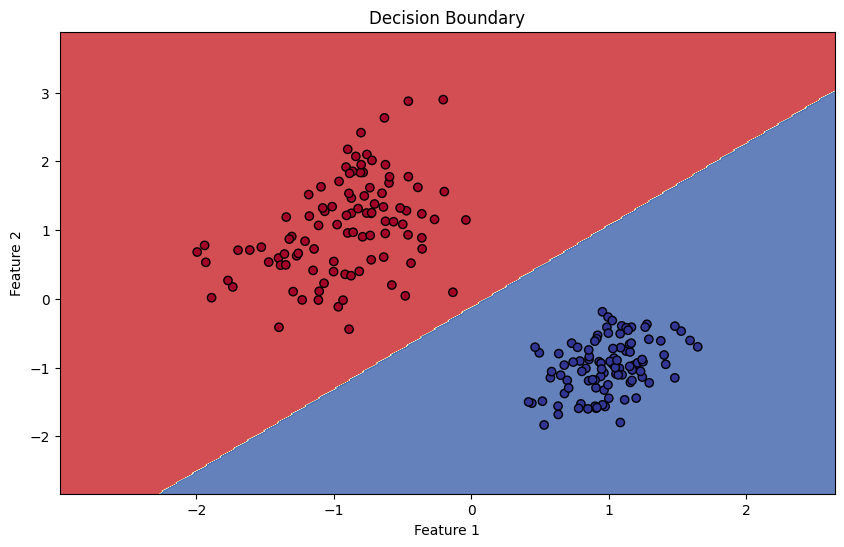

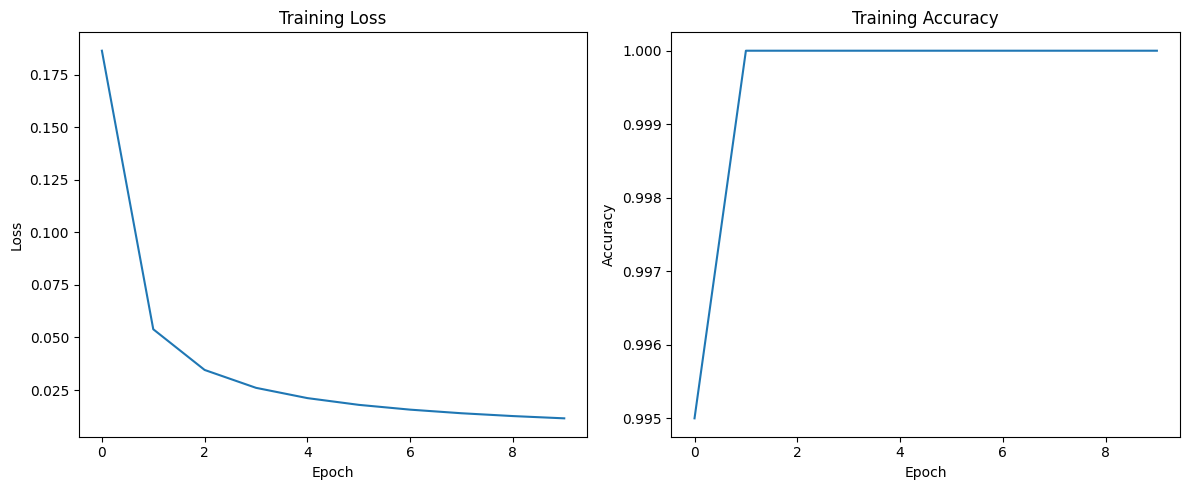

<Figure size 800x600 with 0 Axes>

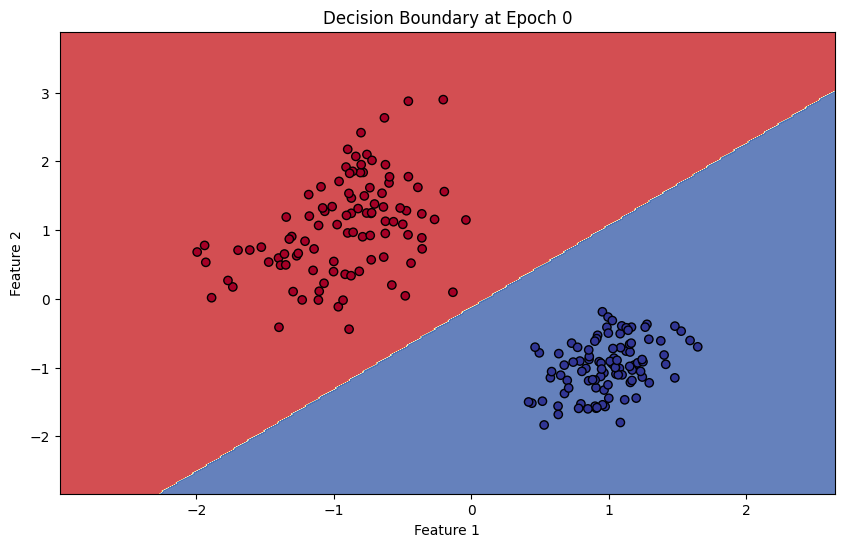

<Figure size 800x600 with 0 Axes>

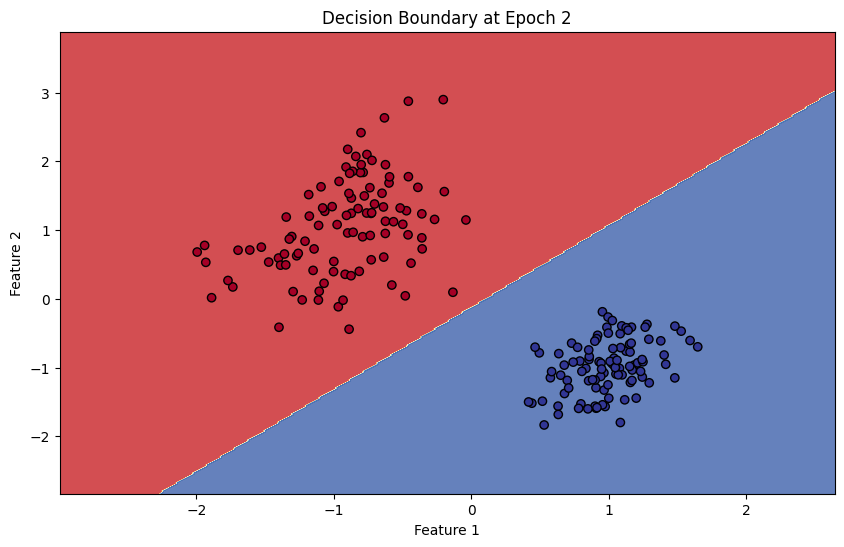

<Figure size 800x600 with 0 Axes>

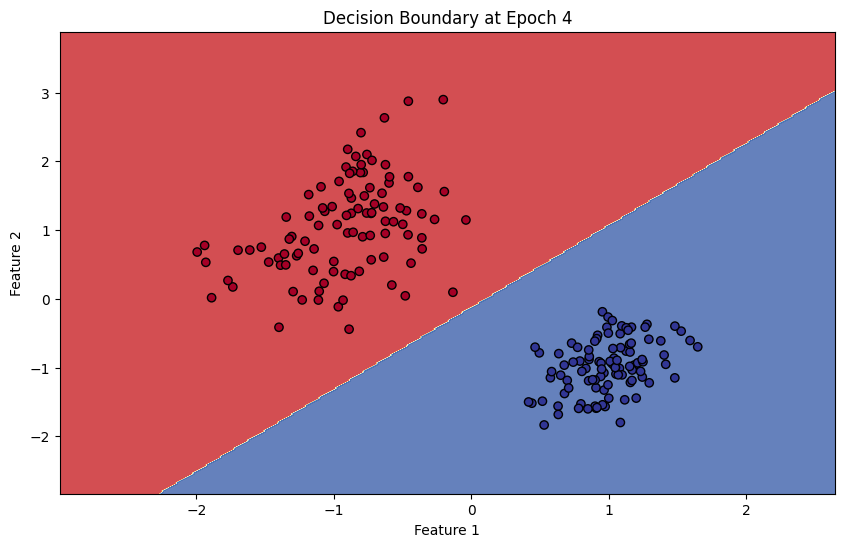

<Figure size 800x600 with 0 Axes>

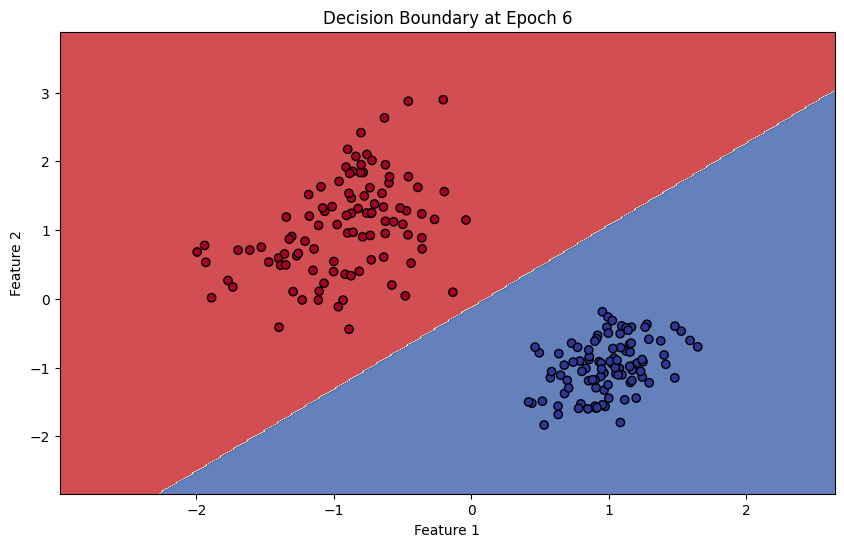

<Figure size 800x600 with 0 Axes>

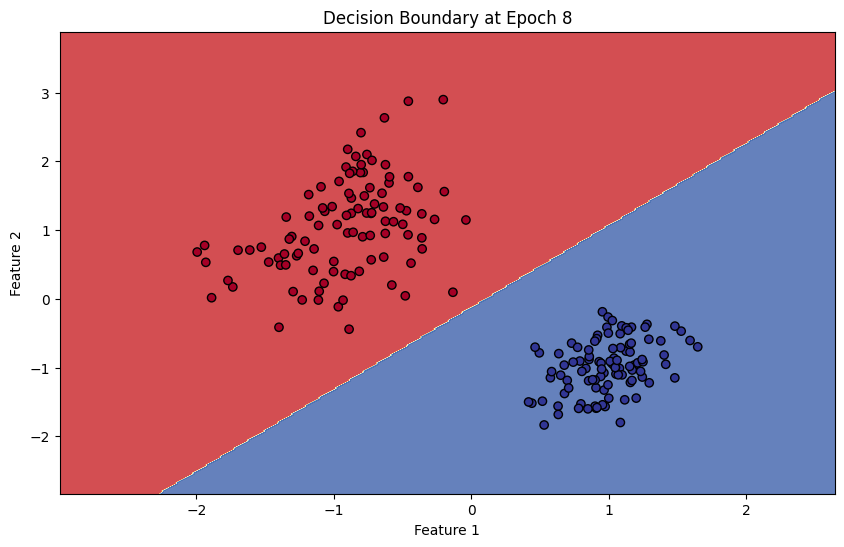

In [5]:
# Task 4: Implement visualization functions
# Create a meshgrid for plotting decision boundaries
# Use your perceptron to make predictions across the grid
# Plot contour lines showing the decision boundary
# Add data points colored by their class

def plot_decision_boundary(perceptron, X, y, weights=None, bias=None):
    # Define the plot boundaries
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Use provided weights or current perceptron weights
    w = weights if weights is not None else perceptron.weights.detach().numpy()
    b = bias if bias is not None else perceptron.bias.item()
    
    # Create predictions for all grid points
    Z = np.zeros(xx.shape)
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            features = np.array([xx[i, j], yy[i, j]])
            # Convert to tensor for perceptron
            features_tensor = torch.tensor(features, dtype=torch.float32)
            Z[i, j] = 1 if perceptron.forward(features_tensor).item() >= 0.5 else 0
    
    # Plot the decision boundary
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k')
    plt.title('Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    return plt

# Create and train the perceptron
perceptron = Perceptron(input_dim=2)
perceptron.train(X, y, epochs=10, lr=0.05)

# Plot final decision boundary
plot_decision_boundary(perceptron, X, y)
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(perceptron.loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(perceptron.accuracy_history)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# Visualize decision boundary evolution
if len(perceptron.weight_history) > 0:
    for i, (weights, bias) in enumerate(perceptron.weight_history):
        plt.figure(figsize=(8, 6))
        plot_decision_boundary(perceptron, X, y, weights.numpy(), bias.item())
        plt.title(f'Decision Boundary at Epoch {i*2}')
        plt.show()

**💡 Tip:** Save the perceptron weights at different epochs to visualize the evolution of the decision boundary.

**⚙️ Test Your Work:**

- Generate the decision boundary plot
- Verify that the boundary correctly separates the two classes
- Ensure all plots have proper labels and titles

## ✅ Success Checklist
- Dataset is created and properly visualized with clear class separation
- Perceptron class is implemented with proper initialization and forward method
- Training algorithm successfully updates weights and reduces loss
- Decision boundary is visualized and correctly separates the classes
- Training progress (loss/accuracy) is properly visualized
- Code runs without errors

## 🔍 Common Issues & Solutions
- Problem: Perceptron doesn't converge to separate classes. 
    - Solution: Ensure your dataset is linearly separable and try a smaller learning rate.

- Problem: Loss fluctuates wildly during training. 
    - Solution: Reduce your learning rate and check for proper weight initialization.

- Problem: Decision boundary visualization is blank or incorrect. 
    - Solution: Verify your meshgrid covers the data range and check prediction function logic.

- Problem: Training is extremely slow. 
    - Solution: Reduce the grid density for visualization and consider using NumPy vectorization.

## 🔑 Key Points
- The perceptron is the simplest form of a neural network, capable of learning linear boundaries.
- Learning rate significantly impacts training stability and convergence speed.
- Visualization of the decision boundary provides key insights into the learning process.
- Understanding this foundational model helps build intuition for more complex neural networks.


## Exemplar Solution

After completing this activity (or if you get stuck!), take a moment to review the exemplar solution. This sample solution can offer insights into different techniques and approaches. 

Reflect on what you can learn from the exemplar solution to improve your coding skills.

Remember, multiple solutions can exist for some problems; the goal is to learn and grow as a programmer by exploring various approaches.

Use the exemplar solution as a learning tool to enhance your understanding and refine your approach to coding challenges.

<details>
    
<summary><strong>Click HERE to see an exemplar solution</strong></summary>    

```python
import torch
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from matplotlib.colors import ListedColormap

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Task 1: Create and visualize synthetic dataset
X, y = make_classification(
    n_samples=200,
    n_features=2,
    n_redundant=0,
    n_informative=2,
    random_state=88,
    n_clusters_per_class=1,
    class_sep=1.0
)

# Convert to numpy arrays
X = np.array(X)
y = np.array(y)

# Visualize dataset
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k')
plt.title('Synthetic Classification Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar()
plt.show()

# Task 2: Build a Perceptron class
class Perceptron:
    def __init__(self, input_dim):
        # Initialize weights with small random values
        self.weights = torch.randn(input_dim, dtype=torch.float32, requires_grad=True) * 0.01
        self.bias = torch.randn(1, dtype=torch.float32, requires_grad=True) * 0.01
        
        # Store training history
        self.weight_history = []
        self.loss_history = []
        self.accuracy_history = []
        
    def forward(self, x):
        # Linear combination of inputs and weights
        linear_output = torch.dot(self.weights, x) + self.bias
        
        # Apply sigmoid activation
        return torch.sigmoid(linear_output)
    
    def calculate_loss(self, y_pred, y_true):
        # Binary cross-entropy loss
        epsilon = 1e-10  # Small value to avoid log(0)
        return -((y_true * torch.log(y_pred + epsilon)) + 
                ((1 - y_true) * torch.log(1 - y_pred + epsilon)))

    # Task 3: Train the Perceptron
    def train(self, X, y, epochs=10, lr=0.01, verbose=True):
        X_tensor = torch.tensor(X, dtype=torch.float32)
        y_tensor = torch.tensor(y, dtype=torch.float32)
        
        for epoch in range(epochs):
            total_loss = 0
            correct = 0
            
            # Store current weights for visualization
            if epoch % 2 == 0:
                self.weight_history.append((self.weights.clone().detach(), 
                                           self.bias.clone().detach()))
            
            for i in range(X_tensor.shape[0]):
                # Forward pass
                y_pred = self.forward(X_tensor[i])
                
                # Calculate loss
                loss = self.calculate_loss(y_pred, y_tensor[i])
                total_loss += loss.item()
                
                # Calculate accuracy
                prediction = 1 if y_pred >= 0.5 else 0
                if prediction == y_tensor[i]:
                    correct += 1
                
                # Calculate error/gradient
                error = y_tensor[i] - y_pred
                
                # Update weights and bias
                self.weights = self.weights + lr * error * X_tensor[i]
                self.bias = self.bias + lr * error
            
            # Calculate epoch statistics
            avg_loss = total_loss / len(X)
            accuracy = correct / len(X)
            
            # Store history
            self.loss_history.append(avg_loss)
            self.accuracy_history.append(accuracy)
            
            # Print progress
            if verbose and (epoch % 2 == 0 or epoch == epochs-1):
                print(f'Epoch {epoch}/{epochs}, Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}')

# Task 4: Visualize Decision Boundaries
def plot_decision_boundary(perceptron, X, y, weights=None, bias=None):
    # Define the plot boundaries
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    
    # Create a mesh grid
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Use provided weights or current perceptron weights
    w = weights if weights is not None else perceptron.weights.detach().numpy()
    b = bias if bias is not None else perceptron.bias.item()
    
    # Create predictions for all grid points
    Z = np.zeros(xx.shape)
    for i in range(xx.shape[0]):
        for j in range(xx.shape[1]):
            features = np.array([xx[i, j], yy[i, j]])
            # Convert to tensor for perceptron
            features_tensor = torch.tensor(features, dtype=torch.float32)
            Z[i, j] = 1 if perceptron.forward(features_tensor).item() >= 0.5 else 0
    
    # Plot the decision boundary
    plt.figure(figsize=(10, 6))
    plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.RdYlBu)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolor='k')
    plt.title('Decision Boundary')
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    return plt

# Create and train the perceptron
perceptron = Perceptron(input_dim=2)
perceptron.train(X, y, epochs=10, lr=0.05)

# Plot final decision boundary
plot_decision_boundary(perceptron, X, y)
plt.show()

# Plot training history
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(perceptron.loss_history)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(1, 2, 2)
plt.plot(perceptron.accuracy_history)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.tight_layout()
plt.show()

# Visualize decision boundary evolution
if len(perceptron.weight_history) > 0:
    for i, (weights, bias) in enumerate(perceptron.weight_history):
        plt.figure(figsize=(8, 6))
        plot_decision_boundary(perceptron, X, y, weights.numpy(), bias.item())
        plt.title(f'Decision Boundary at Epoch {i*2}')
        plt.show()


```